In [39]:
#%%     Imports

%load_ext autoreload
%autoreload 2

# Standard Imports
import tensorflow as tf
import keras_tuner as kt 
import kormos

tf.keras.backend.clear_session()
tf.keras.backend.set_floatx('float64')
tf_float = 'float64'
tf.random.set_seed(42)

import numpy as np
np_float = np.float64

import os
import datetime

# Own imports
import ContinuumMechanics as CM
import layers
import subANNs
import Outputs
import Plots
import Callbacks
import utils
import fit
import build


device = 'gpu:' + str(0) if tf.test.is_gpu_available() else 'cpu:0'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
dataset = 'Ecoflex_loading_unloading'

load_model = False
modelToLoad = '.\\Results_{:}\\20260409-162234'.format(dataset)

pathToData = '.\\datasets\\{:}_data\\'.format(dataset)   

if load_model: 
    outputFolder = modelToLoad
else:
    date = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    outputFolder = '.\\Results_{:}\\'.format(dataset) + date

if not os.path.exists(outputFolder):
    os.makedirs(outputFolder)


In [ ]:


incomp = True
visco = True

uncoupled = True # must be True, was only experementally tested
rateDependent = False # if relaxation times are strain rate dependent

numDir = 0 # number $n$ of preferred material directions $\vec{m}$ (e.g. fibers) to be learned by the model
numTens = 1  # number $R$ of generalized Maxwell models $	ilde{	ns{L}}_r$ to be learned by the model
numExtra = 1 # number $n_f$ of features which parameterize the free energy functions and relaxation times
numExtraStruc = 0 # number of features which parameterize the preferred material direction $\vec{m}_i$ and corresponding wieghts w_i^{(r)}

# for saving and loading    
custom_objects = {
    'dirModel': CM.dirModelOrtho,
    'weightModel': CM.weightModelOrtho,
    'PositiveHeNormal': subANNs.PositiveHeNormal,
    'PositiveVarianceScaling': subANNs.PositiveVarianceScaling,
    'PositiveGlorotNormal': subANNs.PositiveGlorotNormal,
    'PsiSigmaLayer': CM.PsiSigmaLayer, 
    'GradientLayer': CM.GradientLayer,
    'ScaleLayer': layers.ScaleLayer, 
    'stressUpdateLayer': CM.stressUpdateLayer,
    'SparsityRegularizer': utils.SparsityRegularizer
}

In [ ]:
#%% Hyperparameters
#
lr = 0.01
clipnorm = None
lambda_maxwell = 0.0 # penalty to enforce sparsity of the Prony Series

# Time scaling constants (powers of 10)
tau_min = 0
tau_max = 1

# Some activation functions
acti0 = 'tanh'
acti1 = 'sigmoid'
acti2 = 'softplus'
acti3 = 'linear'
acti4 = 'elu'
acti5 = 'squared_softplus'
acti6 = 'neg_squared_softplus'

#
EPOCHS = 10000
earlyStopPatience = 10000

# maximum number N_max of Maxwell elements per generalized Maxwell model
nMaxwell = 3

# Equilibrium free energy: number of layers / neurons per layer
layer_size_psi = [8,] # last layer of shape (1,) is automatically included in the model
activations_psi = [acti2, acti2, acti2]

# Preferred material directions: number of layers / neurons per layer
layer_size_dir = [5,]
activations_dir = [acti2, acti3, acti3]

# Weights of preferred material directions: number of layers / neurons per layer
layer_size_dir = [5,] 
activations_w = [acti2, acti3, acti2]

# Relaxation times: : number of layers / neurons per layer
layer_size_tau = [8,] # last layer of shape (1,) is automatically included in the model
activations_tau = [acti2, acti2, acti2, acti2]

# Non-equilibrium free energy: number of layers / neurons per layer
layer_size_psi_a = [8,] # last layer of shape (1,) is automatically included in the model
activations_psi_a = [acti2, acti2, acti2, acti2]

In [57]:
#%% Data
        
# Training and validation data
trainDs = tf.data.experimental.load(pathToData + "ds_train_defGrad_loocv_50", compression='GZIP')
valDs = tf.data.experimental.load(pathToData + "ds_valid_defGrad_loocv_50", compression='GZIP')

tf.data.experimental.save(trainDs, outputFolder + '\\ds_train_defGrad_loocv_50', compression='GZIP')
tf.data.experimental.save(valDs, outputFolder + '\\ds_valid_defGrad_loocv_50', compression='GZIP')


In [58]:
#%% build the model with prescribed hyperparameters
nSteps = int(np.loadtxt(pathToData + 'n_time_steps.txt'))

if load_model == True:
    model_fit  = Outputs.loadModel(modelToLoad, 'model_6', custom_objects)
    
else:             
    model_fit, model_full = build.build_model(nSteps,
                                                  numTens,
                                                  numDir,
                                                  nMaxwell,
                                                  numExtra,
                                                  numExtraStruc,
                                                  uncoupled,
                                                  rateDependent,
                                                  layer_size_psi,
                                                  activations_psi,
                                                  layer_size_dir,
                                                  activations_dir,
                                                  layer_size_w,
                                                  activations_w,
                                                  layer_size_tau,
                                                  activations_tau,
                                                  layer_size_psi_a, 
                                                  activations_psi_a,
                                                  [tau_min, tau_max],
                                                  lambda_maxwell,
                                                  incomp,
                                                  visco,
                                                  tf_float
                                                )
        
    

Constrained model: 

   model_psi_a_0
      Psi_a_1_1_1:
         kernel constrained
         no bias constraint
      Psi_a_1_2_1:
         kernel constrained
         no bias constraint
      Psi_a_1_3_1:
         kernel constrained
         no bias constraint
      Psi_a_1_1_2:
         kernel constrained
      Psi_a_1_2_2:
         kernel constrained
      Psi_a_1_3_2:
         kernel constrained
   model_Psi
      Psi_1_1:
         kernel constrained
         no bias constraint
      Psi_1_2:
         kernel constrained
   model_tau_0
      Tau_1_1_1:
         no kernel constraint
         no bias constraint
      Tau_1_2_1:
         no kernel constraint
         no bias constraint
      Tau_1_3_1:
         no kernel constraint
         no bias constraint
      Tau_1_1_2:
         no kernel constraint
         no bias constraint
      Tau_1_2_2:
         no kernel constraint
         no bias constraint
      Tau_1_3_2:
         no kernel constraint
         no bias constraint
Tota

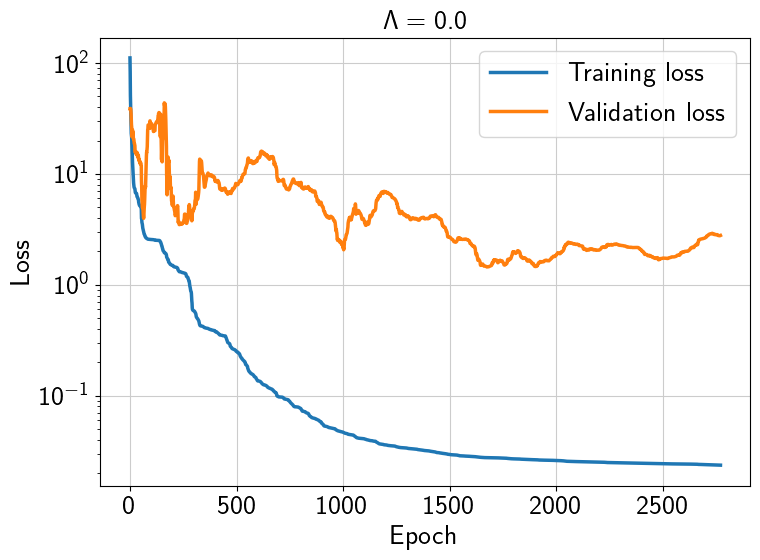

In [59]:
#%% Fit
normalized_error = False
stochastic = False

Maxwell_monitor = None # Callbacks.NonZeroWeightsMonitor(numTens, lambda_prony)
reg_callback = Callbacks.RegularizationCallback(lambda_maxwell, numTens)

if normalized_error:
    # loss = tf.keras.losses.MeanAbsolutePercentageError()
    loss = fit.IndividuallyNormalizedLoss()  
else:
    # loss = tf.keras.losses.MeanSquaredError()
    loss = fit.WeightedLoss()


# stochastic optimizer
if stochastic:

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm, name='optimizer')
    
    #Outputs.saveOptimizerConfig(optimizer, outputFolder=outputFolder)
    #Outputs.saveModelConfig(model_fit, outputFolder=outputFolder) 
    
    # tf.keras.backend.set_value(model_fit.optimizer.learning_rate, 0.1)
    model_fit.compile(
            optimizer=optimizer,
            loss=loss,
            run_eagerly=False
        )
    
    with tf.device('/device:CPU:0'):
        history, model_fit =  fit.stochastic(model_fit, trainDs, EPOCHS, earlyStopPatience, outputFolder, valDs=valDs, Maxwell_monitor=Maxwell_monitor)
                                    
# deterministic optimizer
else:
    with tf.device('/device:CPU:0'):
        history, model_fit = fit.deterministic(model_fit, trainDs, EPOCHS, earlyStopPatience, outputFolder, valDs=valDs, Maxwell_monitor=Maxwell_monitor, loss=loss)


#%%    
Outputs.saveLoss(history, Maxwell_monitor=Maxwell_monitor, outputFolder=outputFolder)
Outputs.plotLoss(history, Maxwell_monitor=Maxwell_monitor, title='$\Lambda = {:}$'.format(lambda_maxwell), outputFolder=outputFolder,scale='log')

In [ ]:
#%% Plot graphs and save model (summary)

Outputs.showModelSummary(model_fit, outputFolder)
Outputs.plotModelGraph(model_fit, outputFolder)
Outputs.saveModel(model_fit, outputFolder)

from exportArchitecture import exportArchitecture
# exportArchitecture(model_fit, outputFolder, weights_local=False)
exportArchitecture(model_fit, outputFolder, weights_local=True)

#%%
# loadedModel = Outputs.loadModel(outputFolder, 'model', custom_objects=custom_objects)





Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 F_input (InputLayer)           [(None, 200, 3, 3)]  0           []                               
                                                                                                  
 tf.compat.v1.shape_1 (TFOpLamb  (4,)                0           ['F_input[0][0]']                
 da)                                                                                              
                                                                                                  
 tf.__operators__.getitem_36 (S  ()                  0           ['tf.compat.v1.shape_1[0][0]']   
 licingOpLambda)                                                                                  
                                                                                        

In [69]:
model_fit.load_weights(outputFolder + '\\ckpt\\ckpt-epoch-1921.ckpt')

1/1 [==============================] - 0s 155ms/step


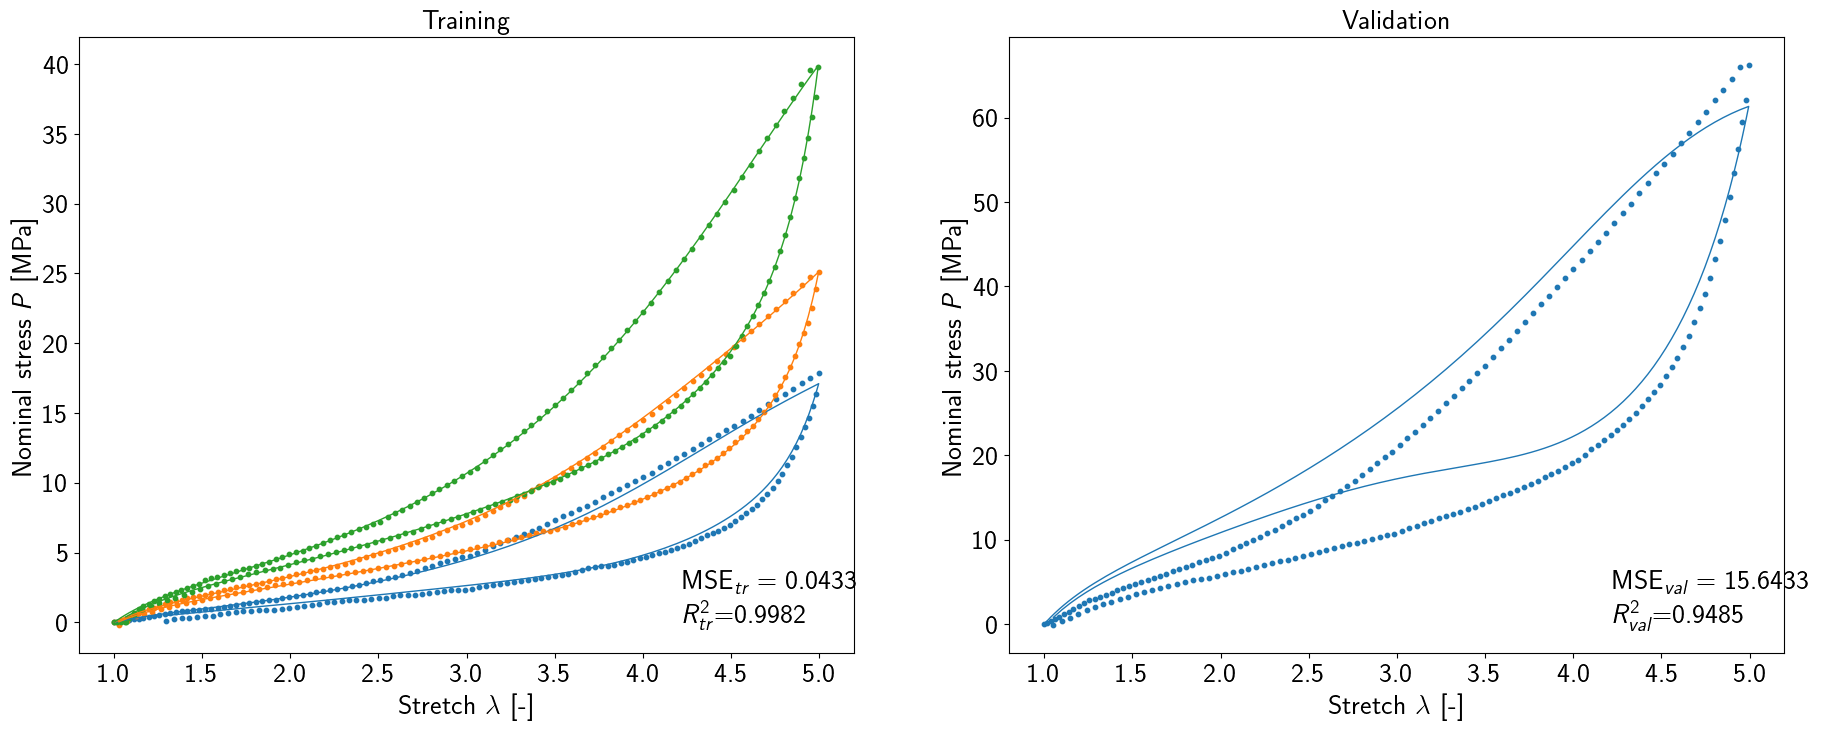

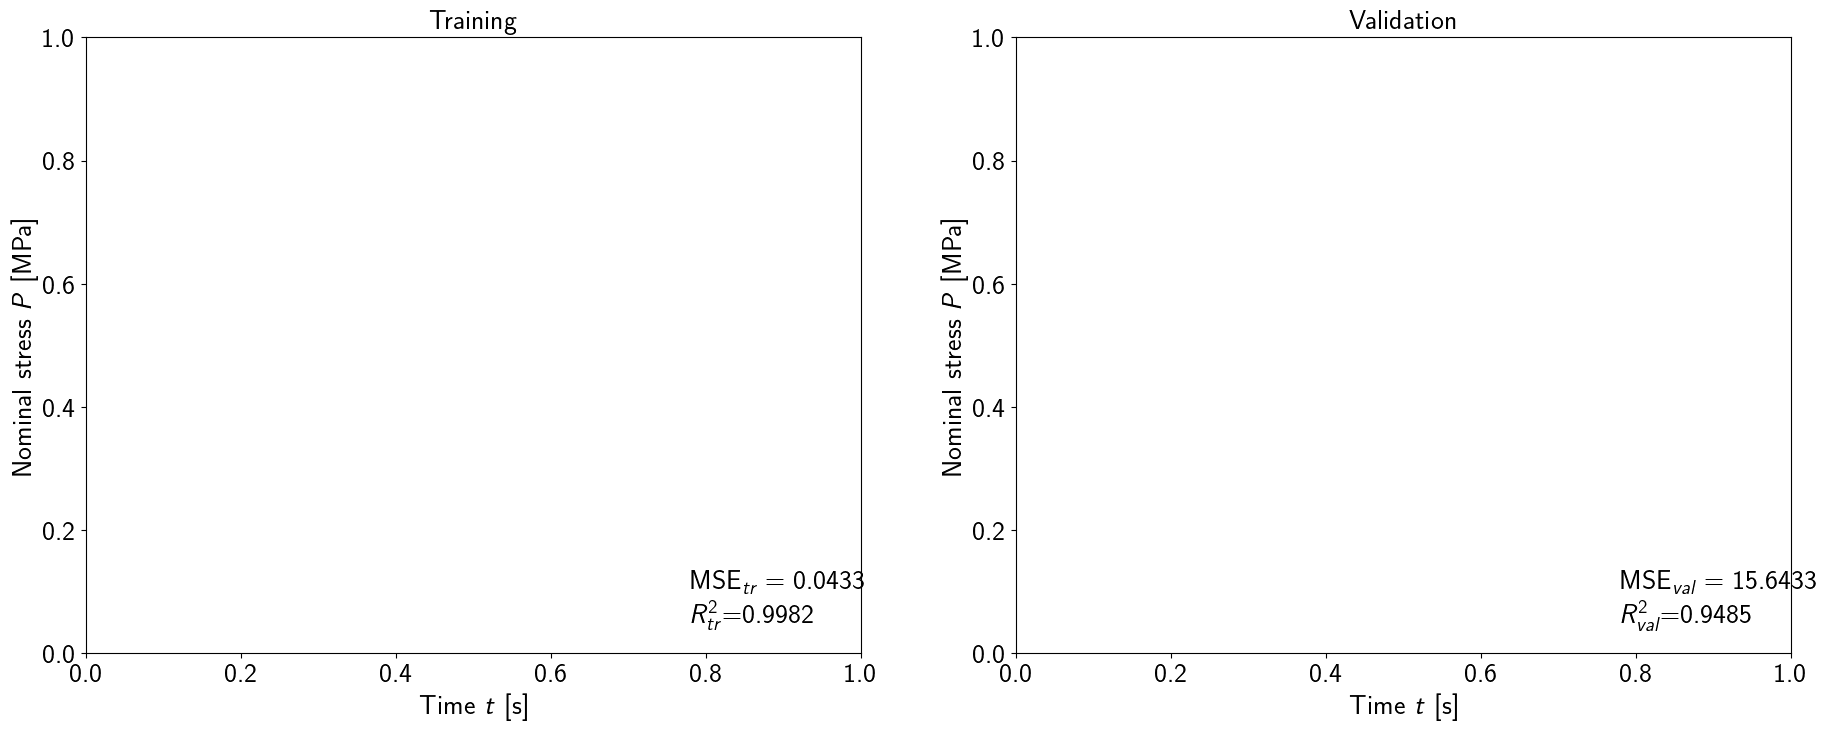

In [70]:
# ckpt = "C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_Hossain\\20251030-185939\\ckpt\\ckpt-epoch-1001.ckpt"
# ckpt = "C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_Hossain\\20251103-190018\\ckpt\\ckpt-epoch-561.ckpt"
# loaded_model = Outputs.loadModel(outputFolder, 'model', custom_objects)
# model_fit.load_weights(ckpt)
#%% individial plotting

# Plots.plot_hossain(model_fit, pathToData, outputFolder, rateDependent)
# Plots.plot_vhb_4905(model_fit, pathToData, outputFolder, rateDependent)
    

#%% Structural Tensor
# Plots.plot_struc_tensor(model_fit, plotly=False, outputFolder=outputFolder)

#%% Stress Response 
# Plots.plot_multi_step_isotropic(model_fit, trainDs, outputFolder)
Plots.plot_stress(model_fit, trainDs, valDs, outputFolder)
# Plots.plot_multi_step(model_fit, trainDs, outputFolder)
# Plots.plot_stress(model_fit, ds_step, ds_step_ref, outputFolder)
        

In [ ]:
# save model architecture JSON to outputFolder
js = model_fit.to_json()
json_path = os.path.join(outputFolder, 'model_architecture.json')
with open(json_path, 'w', encoding='utf-8') as f:
    f.write(js)
print(f"Model JSON saved to: {json_path}")

Model JSON saved to: C:\Users\Kian\Documents\Projekte\ViscoCANN\vCANN\Results_Liao_Thermo\20251125-015147\model_architecture.json


In [ ]:
# create model from saved JSON architecture
json_path = os.path.join(outputFolder, 'model_architecture.json')

with open(json_path, 'r', encoding='utf-8') as f:
    model_json = f.read()

# custom_objects is defined in an earlier cell
try:
    model_from_json = tf.keras.models.model_from_json(model_json, custom_objects=custom_objects)
except Exception as e:
    # helpful error if custom object registration is missing
    print("Failed to create model from JSON. Error:", e)
    print("Ensure all custom objects are present in `custom_objects` dict:", list(custom_objects.keys()))
    raise

print("Model created from JSON:")
model_from_json.summary()

Model created from JSON:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 F_input (InputLayer)           [(None, 300, 3, 3)]  0           []                               
                                                                                                  
 tf.compat.v1.shape (TFOpLambda  (4,)                0           ['F_input[0][0]']                
 )                                                                                                
                                                                                                  
 tf.__operators__.getitem (Slic  ()                  0           ['tf.compat.v1.shape[0][0]']     
 ingOpLambda)                                                                                     
                                                                     

In [37]:
from checkpoint_analysis import parallel_checkpoint_analysis
parallel_checkpoint_analysis(model_fit, pathToData, outputFolder, rateDependent, checkpoint_dir=None, max_workers=None)

Found 377 checkpoints to process
Using 24 parallel workers
Processing checkpoints in parallel...
  ✓ Success Epoch 1
  ✓ Success Epoch 21
  ✓ Success Epoch 41
  ✓ Success Epoch 61
  ✓ Success Epoch 81
  ✓ Success Epoch 101
  ✓ Success Epoch 121
  ✓ Success Epoch 141
  ✓ Success Epoch 161
  ✓ Success Epoch 181
  ✓ Success Epoch 201
  ✓ Success Epoch 221
  ✓ Success Epoch 241
  ✓ Success Epoch 261
  ✓ Success Epoch 281
  ✓ Success Epoch 301
  ✓ Success Epoch 321
  ✓ Success Epoch 341
  ✓ Success Epoch 361
  ✓ Success Epoch 381
  ✓ Success Epoch 401
  ✓ Success Epoch 421
  ✓ Success Epoch 441
  ✓ Success Epoch 461
  ✓ Success Epoch 481
  ✓ Success Epoch 501
  ✓ Success Epoch 521
  ✓ Success Epoch 541
  ✓ Success Epoch 561
  ✓ Success Epoch 581
  ✓ Success Epoch 601
  ✓ Success Epoch 621
  ✓ Success Epoch 641
  ✓ Success Epoch 661
  ✓ Success Epoch 681
  ✓ Success Epoch 701
  ✓ Success Epoch 721
  ✓ Success Epoch 741
  ✓ Success Epoch 761
  ✓ Success Epoch 781
  ✓ Success Epoch 801
  ✓ Suc

{1: {'success': True,
  'error': None,
  'checkpoint_path': 'C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_Ecoflex_loading_unloading\\20260421-193701\\ckpt\\ckpt-epoch-01.ckpt',
  'output_folder': 'C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_Ecoflex_loading_unloading\\20260421-193701\\checkpoint_analysis\\epoch_0001'},
 21: {'success': True,
  'error': None,
  'checkpoint_path': 'C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_Ecoflex_loading_unloading\\20260421-193701\\ckpt\\ckpt-epoch-21.ckpt',
  'output_folder': 'C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_Ecoflex_loading_unloading\\20260421-193701\\checkpoint_analysis\\epoch_0021'},
 41: {'success': True,
  'error': None,
  'checkpoint_path': 'C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_Ecoflex_loading_unloading\\20260421-193701\\ckpt\\ckpt-epoch-41.ckpt',
  'output_folder': 'C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_

In [38]:
from checkpoint_analysis import create_video_from_checkpoint_analysis
video_folder = outputFolder
create_video_from_checkpoint_analysis(video_folder, fps=2, duration_per_frame=0.5)

Found 377 epoch directories
Found 376 PDF files to convert
Converting PDFs to images...
  Converted 10/376 PDFs
  Converted 20/376 PDFs
  Converted 30/376 PDFs
  Converted 40/376 PDFs
  Converted 50/376 PDFs
  Converted 60/376 PDFs
  Converted 70/376 PDFs
  Converted 80/376 PDFs
  Converted 90/376 PDFs
  Converted 100/376 PDFs
  Converted 110/376 PDFs
  Converted 120/376 PDFs
  Converted 130/376 PDFs
  Converted 140/376 PDFs
  Converted 150/376 PDFs
  Converted 160/376 PDFs
  Converted 170/376 PDFs
  Converted 180/376 PDFs
  Converted 190/376 PDFs
  Converted 200/376 PDFs
  Converted 210/376 PDFs
  Converted 220/376 PDFs
  Converted 230/376 PDFs
  Converted 240/376 PDFs
  Converted 250/376 PDFs
  Converted 260/376 PDFs
  Converted 270/376 PDFs
  Converted 280/376 PDFs
  Converted 290/376 PDFs
  Converted 300/376 PDFs
  Converted 310/376 PDFs
  Converted 320/376 PDFs
  Converted 330/376 PDFs
  Converted 340/376 PDFs
  Converted 350/376 PDFs
  Converted 360/376 PDFs
  Converted 370/376 P

'C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_Ecoflex_loading_unloading\\20260421-193701\\checkpoint_analysis\\training_progress_video.mp4'